In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse.linalg import expm_multiply, expm
from scipy.sparse import diags
from utils import *
from ionq_circuit_utils import *

from os import getenv
from os.path import join
import json
import hashlib
import time

import networkx as nx
from random import shuffle, seed

import requests

from braket.circuits import Circuit
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask

# from simuq import QSystem
# from simuq import Qubit
# from simuq.ionq import IonQProvider, IonQAPICircuit

from qiskit import QuantumCircuit, transpile

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
IONQ_API_KEY = getenv('IONQ_API_KEY')

# Helper functions

In [3]:
# Sends job and returns job_id
def send_job(job):
    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}",
        "Content-Type": "application/json"
    }
    req = requests.post("https://api.ionq.co/v0.3/jobs", json=job, headers=headers)
    try:
        job_id = json.loads(req.content)['id']
    except KeyError:
        print(req)
        raise KeyError(f"Error sending job. Error message: {req.content['''message''']}")
    return job_id

In [4]:
def get_ionq_single_job_result(job_id, codewords, use_error_mitigation=False):
    # Get job
    print("Getting job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }

    req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}", headers=headers)
    

    status = json.loads(req.content)['status']
    print(f"Job status: {status}")
    if status == "completed":
        
        headers = {
            "Authorization": f"apiKey {IONQ_API_KEY}"
        }
        if use_error_mitigation:
            params = {"sharpen": "true"} # plural voting aggregation
        else:
            params = {"sharpen": "false"}
        req = requests.get(f"https://api.ionq.co/v0.3/jobs/{job_id}/results", headers=headers, params=params)
        results = json.loads(req.content)
        if "error" in results.keys():
            raise AttributeError(results["message"])
        else:
            freq = np.zeros(len(codewords))
            for i in range(len(codewords)):
                if str(codewords[i]) in results.keys():
                    freq[i] = results[str(codewords[i])]
            return freq
    else:
        raise FileNotFoundError("Job not completed")
    
def get_results(job_ids_path, num_time_points, codewords, use_error_mitigation=False):
    with open(job_ids_path, "r") as f:
        job_ids = json.load(f)
        f.close()

    freq = np.zeros((num_time_points, len(codewords)))
    for i, job_id in enumerate(job_ids):

        freq[i] = get_ionq_single_job_result(job_id, codewords, use_error_mitigation)

    return freq

def cancel_job(job_id):
    print("Cancelling job:", job_id)

    headers = {
        "Authorization": f"apiKey {IONQ_API_KEY}"
    }
    r = requests.put(f"https://api.ionq.co/v0.3/jobs/{job_id}/status/cancel", headers=headers)
    return r

Wave equation implementation

In [6]:
def get_wave_circuit(num_grid_points, t, R, r, encoding="one-hot"):
    N = num_grid_points * 2 + 1
    instructions = []
    dx = R / (num_grid_points - 1)

    # Use randomized first order Trotter
    dt = t / r
    
    for _ in range(r):
        assert encoding == "one-hot"
        '''Second order Trotter'''
        for i in np.arange(0, N-1, 2):
            instructions.append(get_rxx(0.5 * dt / dx, targets=[int(i),int(i+1)]))
            instructions.append(get_ryy(0.5 * dt / dx, targets=[int(i),int(i+1)]))
        for i in np.arange(1, N-1, 2):
            if i == N-2:
                instructions.append(get_rxx(dt / dx, targets=[int(i),int(i+1)]))
                instructions.append(get_ryy(dt / dx, targets=[int(i),int(i+1)]))
            else:
                instructions.append(get_rxx(-dt / dx, targets=[int(i),int(i+1)]))
                instructions.append(get_ryy(-dt / dx, targets=[int(i),int(i+1)]))
                
        for i in np.arange(0, N-1, 2):
            instructions.append(get_rxx(0.5 * dt / dx, targets=[int(i),int(i+1)]))
            instructions.append(get_ryy(0.5 * dt / dx, targets=[int(i),int(i+1)]))

    return instructions

def run_wave(num_grid_points, T, R, r, num_time_points, num_shots, device, save_dir, use_real_machine, 
           job_ids_filename, encoding, use_noisy_sim=False):
    N = 2 * num_grid_points + 1

    task_name = "wave equation"
    dimension = 1
    x_vals = np.linspace(0, R, num_grid_points)
    t_vals = np.linspace(0, T, num_time_points)
    # n = num_qubits_per_dim(N, encoding)

    job_ids = []

    psi_0 = np.zeros(N, dtype=np.complex64)
    psi_0[1::2] = np.sin((np.pi * x_vals))
    psi_0 /= np.linalg.norm(psi_0)

    for i, t in enumerate(t_vals):
        
        print(f"Unitless time: {t : 0.3f}")

        # use braket simulator and get amplitudes of state vector
        instructions = state_prep_circuit(N, dimension, psi_0, encoding)
        instructions += get_wave_circuit(num_grid_points, t, R, r, encoding=encoding)
        native_instructions, _ = get_native_circuit(N, instructions)
        one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
        print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
        # if optimize_circuit:
        #     # Optimize with Qiskit
        #     compiled_circuit = transpile(get_qiskit_circuit(n * dimension, instructions), basis_gates=['rxx', 'rx', 'ry', 'rz'], optimization_level=3)
        #     instructions = get_circuit_from_qiskit(compiled_circuit)
            
        if use_real_machine:
            
            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            time.sleep(1)
            print("Job id:", job_id)
            job_ids.append(job_id)
        else:
            
            # native_instructions, qubit_phase = get_native_circuit(dimension * n, instructions)
            # one_qubit_gate_count, two_qubit_gate_count = get_native_gate_counts(native_instructions)
            # print(f"1q gates: {one_qubit_gate_count}, 2q gates: {two_qubit_gate_count}")
            # circuit = get_braket_native_circuit(native_instructions)
            # for j in range(n * dimension):
            #     circuit.rz(j, -qubit_phase[j] * (2 * np.pi))

            # circuit.amplitude(state=bitstrings)

            # # Run on simulator
            # task = device.run(circuit)
            # # occurrences = get_occurrences(N, task.result().measurements, num_shots, dimension, encoding, periodic=False)
            # # sim_freq[i] = occurrences.flatten() / np.sum(occurrences)

            # amplitudes_res = task.result().values[0]
            # for j in range(N ** dimension):
            #     sim_freq[i,j] = np.abs(amplitudes_res[bitstrings[j]]) ** 2


            # Create the job json and save it
            job = get_ionq_job_json(task_name, N, dimension, num_shots, device, encoding, instructions, use_native_gates=True, noisy_simulator=use_noisy_sim)
            
            print(f"Saving in {save_dir}")
            with open(join(save_dir, f"job_{i}.json"), "w") as f:
                json.dump(job, f, default=int)

            # Send the job and get the job id
            job_id = send_job(job)
            print("Job id:", job_id)
            job_ids.append(job_id)

    print(f"Saving IonQ job ids as {job_ids_filename}")
    with open(join(save_dir, job_ids_filename), "w") as f:
        json.dump(job_ids, f)
        f.close()

# 1D wave equation

In [7]:
DATA_DIR = "experiment_data"
TASK_DIR = "wave"

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)
CURR_DIR = join(CURR_DIR, TASK_DIR)
check_and_make_dir(CURR_DIR)

print(CURR_DIR)

use_real_machine = False
if use_real_machine:
    device = "qpu.aria-1"
    # device = "simulator"
    print("Device:", device)
else:
    device = "simulator"

    print("Device:", device)

experiment_data/wave
Device: simulator


In [24]:
num_grid_points = 8
N = 2 * num_grid_points + 1
r = 4                               # Trotter steps

# N = 9
# r = 10
dimension = 1
encoding = "one-hot"
n = num_qubits_per_dim(N, encoding)
codewords = get_codewords_1d(n, encoding, periodic=False)
bitstrings = get_bitstrings(N, dimension, encoding)

T = 2
R = 1
num_time_points = 16


x_vals = np.linspace(0, R, num_grid_points)
t_vals = np.linspace(0, T, num_time_points)
num_shots = 200

experiment_info = {
    "N": N,
    "dimension": dimension,
    "encoding": encoding,
    "T": T,
    "R": R,
    "num_time_points": num_time_points,
    "r": r,
    "num_shots": num_shots
}

hash_str = hashlib.md5(json.dumps(experiment_info).encode("utf-8")).hexdigest()
SAVE_DIR = join(CURR_DIR, hash_str)
check_and_make_dir(SAVE_DIR)

print("Save dir:", SAVE_DIR)

with open(join(SAVE_DIR, "experiment_info.json"), "w") as f:
    json.dump(experiment_info, f)
    f.close()

# print("Rough estimate of two qubit gate count (not including state prep):", 1.5 * (N-1) * 2 * r)

qpu_job_ids_filename = 'job_ids_qpu.json'
sim_job_ids_filename = 'job_ids_sim.json'
noisy_sim_job_ids_filename = 'job_ids_noisy_sim.json'

Save dir: experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d


In [25]:
if use_real_machine:
    run_wave(num_grid_points, T, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, qpu_job_ids_filename, encoding=encoding)
else:
    run_wave(num_grid_points, T, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, sim_job_ids_filename, encoding=encoding, use_noisy_sim=False)
    run_wave(num_grid_points, T, R, r, num_time_points, num_shots, device, SAVE_DIR, use_real_machine, noisy_sim_job_ids_filename, encoding=encoding, use_noisy_sim=True)


Unitless time:  0.000
1q gates: 33, 2q gates: 26
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: 493d2b40-4841-4dd1-be2c-de8d8c10f6ad
Unitless time:  0.133
1q gates: 33, 2q gates: 218
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: b870cfbf-faef-4eae-9bd8-04e509db710d
Unitless time:  0.267
1q gates: 33, 2q gates: 218
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: 58d25aa0-d69e-42b9-a372-31e9a73053f6
Unitless time:  0.400
1q gates: 33, 2q gates: 218
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: a4e59cdf-447f-4675-9389-fef98b23c107
Unitless time:  0.533
1q gates: 33, 2q gates: 218
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: 2bca5b1f-f278-4855-a244-90ee8a284d63
Unitless time:  0.667
1q gates: 33, 2q gates: 218
Saving in experiment_data/wave/f7e0d0abdf4ca8155158e3f4a27dfa5d
Job id: fcd120d5-30c9-4764-85fc-0626f267c29b
Unitless time:  0.800
1q gates: 33, 2q gates: 2

Get tasks

/home/jli0108/anaconda3/lib/python3.10/site-packages/matplotlib/transforms.py:762: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


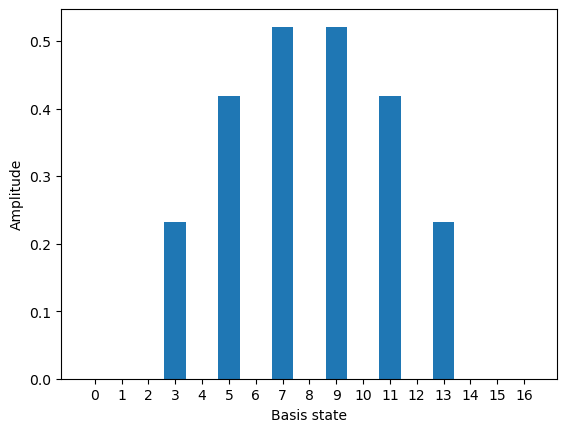

In [56]:
psi_0 = np.zeros(N, dtype=np.complex64)
psi_0[1::2] = np.sin((np.pi * x_vals))
psi_0 /= np.linalg.norm(psi_0)
plt.ylabel("Amplitude")
plt.xlabel("Basis state")
plt.xticks(np.arange(N), np.arange(N))
plt.bar(np.arange(N), psi_0)
plt.savefig("initial_state.svg")

In [27]:

sim_freq = get_results(join(SAVE_DIR, sim_job_ids_filename), num_time_points, codewords)
noisy_sim_freq = get_results(join(SAVE_DIR, noisy_sim_job_ids_filename), num_time_points, codewords)

Getting job: 493d2b40-4841-4dd1-be2c-de8d8c10f6ad
Job status: completed
Getting job: b870cfbf-faef-4eae-9bd8-04e509db710d
Job status: completed
Getting job: 58d25aa0-d69e-42b9-a372-31e9a73053f6
Job status: completed
Getting job: a4e59cdf-447f-4675-9389-fef98b23c107
Job status: completed
Getting job: 2bca5b1f-f278-4855-a244-90ee8a284d63
Job status: completed
Getting job: fcd120d5-30c9-4764-85fc-0626f267c29b
Job status: completed
Getting job: 39e2684d-bfc9-4468-9e1e-73091ebec256
Job status: completed
Getting job: 102e2523-9137-4b92-8a1e-1dd724636c7d
Job status: completed
Getting job: 5feb7d29-68c2-42df-a23a-42dfcf6892b6
Job status: completed
Getting job: 8b5bc2b3-3ebc-4e5e-9654-bf3505e6e4d7
Job status: completed
Getting job: 4dcc23d1-0b7c-4a5b-8fed-65d4d73e047c
Job status: completed
Getting job: 2d099b01-72c9-4093-8112-d9ef096a78af
Job status: completed
Getting job: 4afc3ce9-d113-4e07-97a0-517471380f90
Job status: completed
Getting job: 585cb760-4d14-4b2f-a82f-ed5ee5983dca
Job status: co

Post-processing

In [28]:
sim_freq_normalized = np.zeros_like(sim_freq)
for i in range(num_time_points):
    if np.sum(sim_freq[i]) > 0:
        sim_freq_normalized[i] = sim_freq[i] / np.sum(sim_freq[i])
# Only look at every other qubit
sim_freq_normalized = sim_freq_normalized[:,1::2]

noisy_sim_freq_normalized = np.zeros_like(noisy_sim_freq)
for i in range(num_time_points):
    if np.sum(noisy_sim_freq[i]) > 0:
        noisy_sim_freq_normalized[i] = noisy_sim_freq[i] / np.sum(noisy_sim_freq[i])
noisy_sim_freq_normalized = noisy_sim_freq_normalized[:,1::2]

# ionq_freq_normalized = np.zeros_like(ionq_freq)
# for i in range(num_time_points):
#     if np.sum(ionq_freq[i]) > 0:
#         ionq_freq_normalized[i] = ionq_freq[i] / np.sum(ionq_freq[i])

# ionq_freq_normalized = ionq_freq_normalized[:,1::2]
# num_samples_subspace_ionq = np.sum(ionq_freq, axis=1) * num_shots


Ground truth

In [29]:
psi_0 = np.zeros(2 * num_grid_points + 1)
psi_0[:num_grid_points] = np.sin((np.pi * x_vals))
psi_0 /= np.linalg.norm(psi_0)
B = np.zeros((num_grid_points,num_grid_points+1))
B[0,0] = 1
B[-1,-1] = 1
for i in np.arange(1,num_grid_points):
    B[i-1,i] = 1
    B[i,i] = -1

B /= (1 / (num_grid_points - 1))

H = np.block([[np.zeros((num_grid_points,num_grid_points)), np.conj(B)],[B.T, np.zeros((num_grid_points+1,num_grid_points+1))]])
psi = expm_multiply(-1j * H, psi_0, start=0, stop=T, num=num_time_points)
ideal_dist = np.abs(psi[:,:num_grid_points]) ** 2

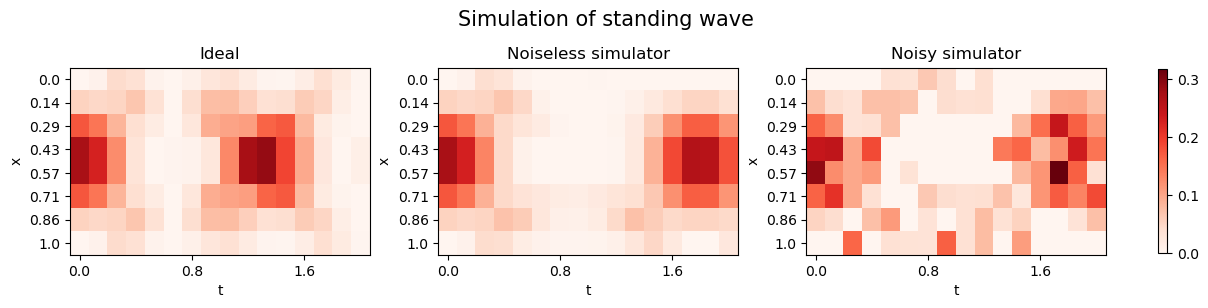

In [47]:
labels = ["Ideal", "Noiseless simulator", "Noisy simulator"]#, "IonQ"]

fig, axs = plt.subplots(1, len(labels), constrained_layout=True, facecolor="white", figsize=(12,3))

max_prob = max(np.max(ideal_dist), np.max(sim_freq_normalized), np.max(noisy_sim_freq_normalized))#, np.max(ionq_freq_normalized))
im = axs[0].matshow(ideal_dist.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[1].matshow(sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
axs[2].matshow(noisy_sim_freq_normalized.T, vmin=0, vmax=max_prob, cmap='Reds')
# axs[2].matshow(ionq_freq_normalized.T, vmin=0, vmax=max_prob)

aspect = 1.25
for i in range(len(labels)):
    axs[i].set_aspect(aspect)
    
    axs[i].set_ylabel("x")
    axs[i].set_yticks(np.arange(ideal_dist.shape[1])[::1])
    axs[i].set_yticklabels([str(round(float(label), 2)) for label in x_vals[::1]])
    axs[i].set_title(labels[i])

    axs[i].set_xlabel("t")
    axs[i].xaxis.set_ticks_position("bottom")
    axs[i].set_xticks(np.arange(ideal_dist.shape[0])[::6])
    axs[i].set_xticklabels([str(round(float(label), 3)) for label in t_vals[::6]])

    

fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.75)
fig.suptitle("Simulation of standing wave", fontsize=15)
plt.savefig("standing_wave.svg")
plt.show()